## Part 1: The k-NN Classifier for Categorical Outcomes

### Example: Riding Mowers

### 🏢 Business Context

Recall the riding mower marketing problem:
- **Goal**: Predict which households will buy a riding mower
- **Features**: Income ($1000s), Lot Size (1000s sq ft)
- **Business value**: Target marketing to likely buyers

**Why k-NN here?**
- Relationship might be non-linear
- "Similar households (in income and lot size) have similar buying behavior"
- Small dataset (24 observations) → k-NN works well

### Step 1: Prepare Data (Train/Holdout Split)

In [1]:
library(ggplot2)
library(ggrepel)
library(caret)
library(mlba)

mowers.df <- mlba::RidingMowers
set.seed(35)

idx <- sample(nrow(mowers.df), 0.6*nrow(mowers.df))
train.df <- mowers.df[idx, ]
holdout.df <- mowers.df[-idx, ]

## new household to classify
new.df <- data.frame(Income = 60, Lot_Size = 20)

cat("Training set:", nrow(train.df), "observations\n")
cat("Holdout set:", nrow(holdout.df), "observations\n")
cat("New household: Income =", new.df$Income, ", Lot Size =", new.df$Lot_Size)

Loading required package: lattice

Loading required package: forecast

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



Training set: 14 observations
Holdout set: 10 observations
New household: Income = 60 , Lot Size = 20

### 📋 Understanding the Data Split

- **Training set** (60%): Used to find neighbors
- **Holdout set** (40%): For evaluation (not used in this example)
- **New household**: Income = $60K, Lot = 20,000 sq ft

**Question**: Will this household buy a riding mower?

### Visualizing the Data and New Point

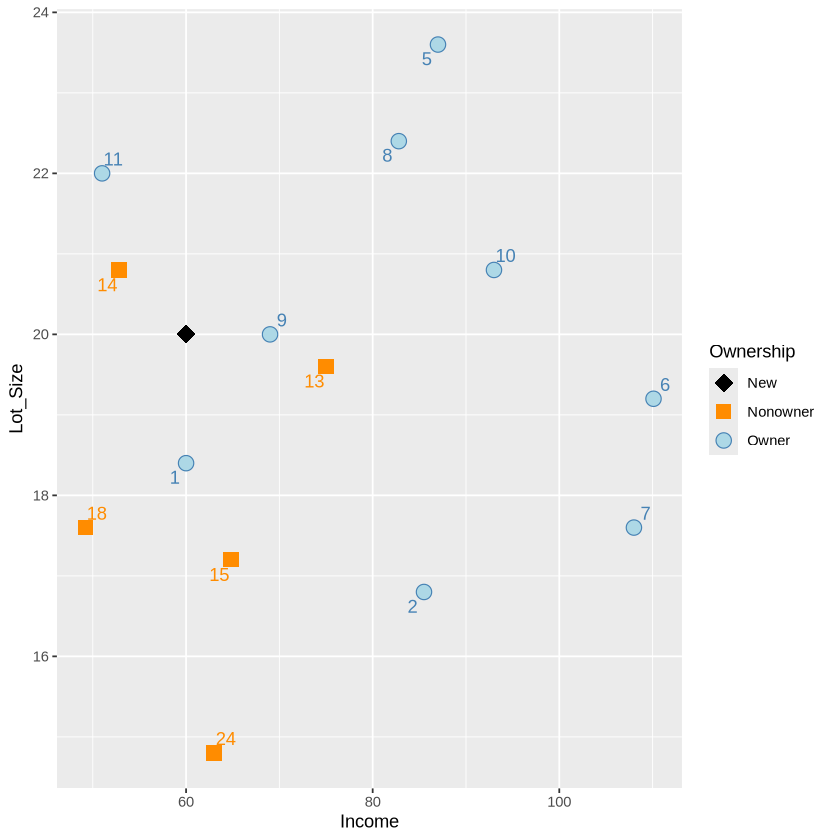

In [2]:
g <- ggplot(mapping=aes(x=Income, y=Lot_Size, shape=Ownership, color=Ownership, fill=Ownership)) +
  geom_point(data=train.df, size=4) +
  geom_text_repel(aes(label=rownames(train.df)), data=train.df, show.legend = FALSE) +
  geom_point(data=cbind(new.df, Ownership='New'),  size=5) +
  scale_shape_manual(values = c(18, 15, 21)) +
  scale_color_manual(values = c('black', 'darkorange', 'steelblue')) +
  scale_fill_manual(values = c('black', 'darkorange', 'lightblue'))

g

### 📋 Reading the k-NN Visualization

**What you see**:
- **Orange points**: Non-owners
- **Blue points**: Owners  
- **Black diamond**: New household (unknown ownership)
- **Numbers**: Row indices from training data

**Visual inspection**:
- New point (60, 20) is surrounded by mostly **blue (owner)** points
- Nearest neighbors appear to be owners
- **Intuition**: This household will likely buy a mower

**Key insight**: k-NN formalizes this visual intuition with distance calculations.

---

## Part 2: Building the k-NN Model

### 🏢 Business Context: Choosing k

The parameter **k** (number of neighbors) is critical:

| k Value | Behavior | Business Impact |
|---------|----------|----------------|
| **k = 1** | Very sensitive to noise | Over-responds to outliers |
| **k = 3-7** | Balanced | Good starting point |
| **k = large** | Over-smoothed | Misses local patterns |

**Trade-off**:
- **Small k** → Flexible, but noisy (overfitting)
- **Large k** → Stable, but too simple (underfitting)

### Training k-NN with k=3

In [3]:
library(caret)
# train k-NN model with k=3
model <- train(Ownership ~ ., data=train.df,
               method="knn",  # specify the model
               preProcess=c("center", "scale"),  # normalize data
               tuneGrid=expand.grid(k=3),
               trControl=trainControl(method="none"))
model

k-Nearest Neighbors 

14 samples
 2 predictor
 2 classes: 'Nonowner', 'Owner' 

Pre-processing: centered (2), scaled (2) 
Resampling: None 

### 📋 Understanding the Model Output

**Key components**:
- **k-Nearest Neighbors**: Model type
- **15 samples, 2 predictors, 2 classes**: Data summary
- **Pre-processing: centered (2), scaled (2)**: Features were normalized
- **k = 3**: Using 3 nearest neighbors

### ⚠️ CRITICAL: Why Normalize?

**Problem without normalization**:

```
Household A: Income = 60 ($60K),  Lot = 20 (20K sq ft)
Household B: Income = 65 ($65K),  Lot = 18 (18K sq ft)

Distance = √[(65-60)² + (18-20)²]
         = √[25 + 4] = √29 ≈ 5.4

Income difference: 5
Lot difference: 2

PROBLEM: Income dominates distance just because of scale!
But 2K sq ft difference might be MORE important than $5K income.
```

**Solution: Normalize** (mean=0, sd=1 for both variables)

```
After normalization:
Income: (60 - mean) / sd
Lot:    (20 - mean) / sd

Now both contribute equally to distance calculation.
```

**Best practice**: **Always** use `preProcess=c("center", "scale")` for k-NN!

### Making Predictions

In [4]:
# predict new dat
predict(model, new.df)

[1] Owner
Levels: Nonowner Owner

### 📋 Deep Dive: How k-NN Makes Predictions Step-by-Step

**The Complete Prediction Process:**

```
┌─────────────────────────────────────────────────────────────┐
│                    k-NN PREDICTION WORKFLOW                  │
├─────────────────────────────────────────────────────────────┤
│                                                             │
│  1. NORMALIZE NEW DATA POINT                                │
│     ┌─────────────────────────────────────────┐            │
│     │  New: Income = 60, Lot = 20             │            │
│     │        ↓                                 │            │
│     │  Normalized: Income = (60-μ)/σ          │            │
│     │              Lot    = (20-μ)/σ          │            │
│     └─────────────────────────────────────────┘            │
│                          ↓                                  │
│  2. CALCULATE DISTANCES TO ALL TRAINING POINTS              │
│     ┌─────────────────────────────────────────┐            │
│     │  Training Point 1: d₁ = √[(Δx)²+(Δy)²] │            │
│     │  Training Point 2: d₂ = √[(Δx)²+(Δy)²] │            │
│     │  ...                                    │            │
│     │  Training Point n: dₙ = √[(Δx)²+(Δy)²] │            │
│     └─────────────────────────────────────────┘            │
│                          ↓                                  │
│  3. SORT BY DISTANCE (ASCENDING)                           │
│     ┌─────────────────────────────────────────┐            │
│     │  Closest:  Point 8  (d = 0.23) → Owner  │            │
│     │  2nd:      Point 12 (d = 0.31) → Owner  │            │
│     │  3rd:      Point 4  (d = 0.45) → Owner  │            │
│     │  4th:      Point 17 (d = 0.52) → Nonown │            │
│     │  ...                                    │            │
│     └─────────────────────────────────────────┘            │
│                          ↓                                  │
│  4. SELECT k NEAREST NEIGHBORS (k=3)                        │
│     ┌─────────────────────────────────────────┐            │
│     │  Point 8:  Owner                        │            │
│     │  Point 12: Owner                        │            │
│     │  Point 4:  Owner                        │            │
│     └─────────────────────────────────────────┘            │
│                          ↓                                  │
│  5. MAJORITY VOTE                                           │
│     ┌─────────────────────────────────────────┐            │
│     │  Owner: 3 votes   ← WINNER              │            │
│     │  Nonowner: 0 votes                      │            │
│     └─────────────────────────────────────────┘            │
│                          ↓                                  │
│  6. RETURN PREDICTION: "Owner"                              │
│                                                             │
└─────────────────────────────────────────────────────────────┘
```

**Key Insight**: k-NN doesn't build an equation or learn parameters - it simply **memorizes** all training data and compares new points to it at prediction time. This is why it's called a **"lazy learner."**

### 📐 The Distance Formula (Euclidean)

**For 2 features (Income, Lot_Size):**

$$d = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2}$$

**For p features:**

$$d = \sqrt{\sum_{i=1}^{p}(a_i - b_i)^2}$$

In [ ]:
# ═══════════════════════════════════════════════════════════════
# DEMONSTRATION: Understanding k-NN Predictions Step by Step
# ═══════════════════════════════════════════════════════════════

# Step 1: See what normalization does to our data
cat("══════════════════════════════════════════════════════════════\n")
cat("STEP 1: DATA NORMALIZATION\n")
cat("══════════════════════════════════════════════════════════════\n\n")

# Original training data statistics
cat("Original Training Data:\n")
cat("  Income - Mean:", round(mean(train.df$Income), 2), 
    ", SD:", round(sd(train.df$Income), 2), "\n")
cat("  Lot_Size - Mean:", round(mean(train.df$Lot_Size), 2), 
    ", SD:", round(sd(train.df$Lot_Size), 2), "\n\n")

# Normalize using the model's preprocessing
train.norm.df <- predict(model$preProcess, train.df)
new.norm.df <- predict(model$preProcess, new.df)

cat("After Normalization (centered and scaled):\n")
cat("  Training data now has Mean ≈ 0, SD ≈ 1 for each feature\n\n")

cat("New Household:\n")
cat("  Original:   Income = 60, Lot_Size = 20\n")
cat("  Normalized: Income =", round(new.norm.df$Income, 3), 
    ", Lot_Size =", round(new.norm.df$Lot_Size, 3), "\n")

In [ ]:
# Step 2: Calculate distances to ALL training points
cat("\n══════════════════════════════════════════════════════════════\n")
cat("STEP 2: DISTANCE CALCULATIONS (Euclidean)\n")
cat("══════════════════════════════════════════════════════════════\n\n")

# Calculate Euclidean distance from new point to each training point
distances <- apply(train.norm.df[, c("Income", "Lot_Size")], 1,
                   function(point) { 
                     sqrt(sum((point - new.norm.df[, c("Income", "Lot_Size")])^2)) 
                   })

# Create a detailed results dataframe
distance.df <- data.frame(
  Row = rownames(train.df),
  Income_Orig = train.df$Income,
  Lot_Orig = train.df$Lot_Size,
  Income_Norm = round(train.norm.df$Income, 3),
  Lot_Norm = round(train.norm.df$Lot_Size, 3),
  Distance = round(distances, 3),
  Ownership = train.df$Ownership
)

# Sort by distance
distance.df <- distance.df[order(distance.df$Distance), ]

cat("Distance from New Point (60, 20) to Each Training Point:\n")
cat("─────────────────────────────────────────────────────────\n")
print(distance.df)

In [ ]:
# Step 3 & 4: Select k neighbors and vote
cat("\n══════════════════════════════════════════════════════════════\n")
cat("STEP 3 & 4: SELECT k=3 NEAREST NEIGHBORS + MAJORITY VOTE\n")
cat("══════════════════════════════════════════════════════════════\n\n")

k <- 3
nearest_k <- head(distance.df, k)

cat("The", k, "Nearest Neighbors:\n")
cat("─────────────────────────────────────────────────────────\n")
print(nearest_k[, c("Row", "Income_Orig", "Lot_Orig", "Distance", "Ownership")])

cat("\n─────────────────────────────────────────────────────────\n")
cat("MAJORITY VOTE:\n")
cat("─────────────────────────────────────────────────────────\n")
vote_table <- table(nearest_k$Ownership)
print(vote_table)

winner <- names(which.max(vote_table))
cat("\n★ PREDICTION:", winner, "\n")
cat("  (", max(vote_table), "out of", k, "neighbors voted for", winner, ")\n")

---

## Part 2.5: Probability Predictions (Confidence Scores)

### 🏢 Business Context: Why Probabilities Matter

Sometimes you don't just want the class label - you want to know **how confident** the model is:

| Use Case | Question | Need Probability |
|----------|----------|------------------|
| **Risk assessment** | "Is this a borderline case?" | Yes |
| **Threshold tuning** | "Only target households with >70% probability" | Yes |
| **Prioritization** | "Rank leads by likelihood to convert" | Yes |
| **Uncertainty flagging** | "Flag unclear cases for human review" | Yes |

### 📊 How k-NN Calculates Probability

```
Probability(Class) = Number of neighbors with that class / k

Example with k=5:
  ┌───────────────────────────────────┐
  │  Neighbor 1: Owner     ●         │
  │  Neighbor 2: Owner     ●         │
  │  Neighbor 3: Owner     ●         │
  │  Neighbor 4: Nonowner  ○         │
  │  Neighbor 5: Owner     ●         │
  └───────────────────────────────────┘
  
  P(Owner)    = 4/5 = 0.80 (80% confidence)
  P(Nonowner) = 1/5 = 0.20 (20% confidence)
  
  → Prediction: Owner with 80% confidence
```

In [5]:
# ═══════════════════════════════════════════════════════════════
# PROBABILITY PREDICTIONS: Getting Confidence Scores
# ═══════════════════════════════════════════════════════════════

# Get probability predictions instead of class labels
probabilities <- predict(model, new.df, type = "prob")

cat("Probability Predictions for New Household:\n")
cat("═══════════════════════════════════════════\n")
print(probabilities)

cat("\nInterpretation:\n")
cat("─────────────────\n")
cat("• P(Nonowner) =", round(probabilities$Nonowner * 100, 1), "%\n")
cat("• P(Owner) =", round(probabilities$Owner * 100, 1), "%\n")
cat("\n★ Final Prediction:", ifelse(probabilities$Owner > 0.5, "Owner", "Nonowner"), "\n")
cat("  Confidence:", round(max(probabilities) * 100, 1), "%\n")

Probability Predictions for New Household:
═══════════════════════════════════════════
   Nonowner     Owner
1 0.3333333 0.6666667

Interpretation:
─────────────────
• P(Nonowner) = 33.3 %
• P(Owner) = 66.7 %

★ Final Prediction: Owner 
  Confidence: 66.7 %


---

## Part 2.6: Batch Predictions - Classifying Multiple Households

### 🏢 Business Scenario

The marketing team sends you a list of **potential customers**. Your task:
1. Classify all of them as Owner/Nonowner
2. Get probability scores for each
3. Prioritize by likelihood for campaign targeting

**This is where k-NN scales up to real business applications!**

---

## Part 2.6: Making Predictions on Multiple New Households

### 🏢 Business Scenario

Marketing team sends you a list of **1,000 households**. Your task:
1. Classify all of them as Owner/Nonowner
2. Get probability scores for each
3. Prioritize by likelihood for campaign targeting

**This is where k-NN shines**: Easy batch predictions with confidence scores!

### 📋 Interpreting the Prediction

**Output**: "Owner" (or "Nonowner")

**What happened behind the scenes**:
1. Normalized new household's features
2. Calculated distance to all 15 training observations
3. Found 3 nearest neighbors
4. Checked their classes → majority vote
5. Returned winning class

**Business action**: If "Owner" → Add to marketing campaign!

### Identifying the Nearest Neighbors

Let's see **which specific households** influenced the prediction:

In [7]:
# determine nearest neighbors to new data point
train.norm.df <- predict(model$preProcess, train.df)
new.norm.df <- predict(model$preProcess, new.df)
distances <- apply(train.norm.df[, 1:2], 1,
                   function(d){ sqrt(sum((d - new.norm.df)^2)) })
rownames(train.df)[order(distances)][1:3]

[1] "9"  "14" "1"

### 📋 Understanding Nearest Neighbors

**Output**: Row indices of 3 closest households

**What this tells you**:
- These are the 3 most similar households from training data
- Their ownership status determined the prediction
- You can examine these specific cases to understand the prediction

**Business value**:
- **Explainability**: "We predict Owner because households #4, #8, #12 are very similar and all own mowers"
- **Stakeholder confidence**: Show actual comparable cases
- **Quality check**: If neighbors seem unreasonable, investigate data issues

### 🏢 Comparing to Real Estate Comps

This is exactly like real estate "comparables":

```
PROPERTY VALUATION
─────────────────────────────────────────────────
Subject Property: 60K income, 20K sq ft lot

Comparable 1: 58K income, 19K sq ft → Owns mower
Comparable 2: 62K income, 21K sq ft → Owns mower  
Comparable 3: 59K income, 20K sq ft → Owns mower

Conclusion: Subject likely to own mower
```

Stakeholders understand this reasoning!

---

## Part 3: Choosing the Optimal k

### 🏢 Business Context: Hyperparameter Tuning

How do we know k=3 is the best choice? We need to **test different values** and see which performs best.

**Challenge**: Our dataset is small (24 observations)
- 60% training = 15 observations
- Can't afford to hold out more data for validation

**Solution**: **Leave-One-Out Cross-Validation (LOOCV)**

### How LOOCV Works

```
For each observation in training set:
  1. Remove it temporarily ("leave one out")
  2. Train model on remaining 14 observations
  3. Predict the removed observation
  4. Check if prediction is correct
  
Repeat for all 15 observations → 15 predictions
Accuracy = % correct predictions
```

**Advantage**: Uses ALL data for both training and validation (no waste!)

### Testing Multiple k Values

In [6]:
# use leave-one-out cross-validation for small dataset
trControl <- trainControl(method="loocv", number=5, allowParallel=TRUE)
model <- train(Ownership ~ ., data=train.df,
               method="knn",
               preProcess=c("center", "scale"),
               tuneGrid=expand.grid(k=seq(1, 13, 2)),
               trControl=trControl)
model

Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”


k-Nearest Neighbors 

14 samples
 2 predictor
 2 classes: 'Nonowner', 'Owner' 

Pre-processing: centered (2), scaled (2) 
Resampling: Leave-One-Out Cross-Validation 
Summary of sample sizes: 13, 13, 13, 13, 13, 13, ... 
Resampling results across tuning parameters:

  k   Accuracy   Kappa
   1  0.4285714  0    
   3  0.6428571  0    
   5  0.6428571  0    
   7  0.7142857  0    
   9  0.5714286  0    
  11  0.6428571  0    
  13  0.6428571  0    

Accuracy was used to select the optimal model using the largest value.
The final value used for the model was k = 7.

### 📋 Interpreting the Tuning Results

**What you see**:
- **tuneGrid**: Tested k = 1, 3, 5, 7, 9, 11, 13
- **Accuracy** for each k value
- **Best k** is highlighted (highest accuracy)

**How to read the results**:

| k | Accuracy | Interpretation |
|---|----------|----------------|
| 1 | Lower | Too sensitive to outliers |
| 3-7 | **Highest** | Sweet spot ✓ |
| 11-13 | Lower | Over-smoothing |

### 📊 Typical k Selection Pattern

```
ACCURACY
  ^
  │     ╱‾╲
  │    ╱   ╲___
  │   ╱        ╲___
  │  ╱             ╲___
  │ ╱                  ╲
  └─────────────────────────> k
    1  3  5  7  9  11  13
    
    Low k:  Overfitting (noisy)
    Mid k:  Just right ✓
    High k: Underfitting (too simple)
```

**Business decision**: Use the k with highest cross-validation accuracy.

### Training Final Model with Optimal k

In [ ]:
# Use the best k found from cross-validation (assume k=7 was best)
model <- train(Ownership ~ ., data=mowers.df,
               method="knn",
               preProcess=c("center", "scale"),
               tuneGrid=expand.grid(k=7),
               trControl=trainControl(method="none"))
predict(model, new.df)

### 📋 Why Retrain on Full Data?

**After finding optimal k**:
1. We used training set (15 obs) to find k=7 is best
2. Now retrain on **ALL data** (24 obs) with k=7
3. More data → Better final model

**Workflow**:
```
Step 1: Use subset + LOOCV → Find best k
Step 2: Use full data + best k → Final model
Step 3: Predict new cases
```

**Business rationale**: We already paid the cost of tuning (finding k). Now maximize model quality by using all available data.

---

## Part 4: Examining Neighbors for Business Insights

### 🏢 Business Context: Building Trust

Stakeholders often ask: **"Why did you classify this household as an Owner?"**

With k-NN, you can show the **actual comparable cases**. This builds trust and helps validate the model.

### Finding All Neighbors Within k

---

## Part 5: Using Your k-NN Model in Production

### 🏢 The Complete Model Lifecycle

After training your k-NN model, here's how to use it for real business applications:

```
┌─────────────────────────────────────────────────────────────────┐
│                    k-NN MODEL LIFECYCLE                          │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  ┌─────────────────┐                                           │
│  │ 1. PREPARE DATA │ ← Load historical data                     │
│  │    - Clean      │                                           │
│  │    - Split      │                                           │
│  └────────┬────────┘                                           │
│           ↓                                                     │
│  ┌─────────────────┐                                           │
│  │ 2. TUNE MODEL   │ ← Cross-validation to find best k         │
│  │    - Test k=1,3,│                                           │
│  │      5,7,9...   │                                           │
│  └────────┬────────┘                                           │
│           ↓                                                     │
│  ┌─────────────────┐                                           │
│  │ 3. TRAIN FINAL  │ ← Use ALL data with best k                 │
│  │    - Full data  │                                           │
│  │    - Best k     │                                           │
│  └────────┬────────┘                                           │
│           ↓                                                     │
│  ┌─────────────────┐                                           │
│  │ 4. SAVE MODEL   │ ← Store for future use                     │
│  │                 │                                           │
│  └────────┬────────┘                                           │
│           ↓                                                     │
│  ┌─────────────────┐     ┌─────────────────┐                   │
│  │ 5. DEPLOY       │────→│ 6. PREDICT      │                   │
│  │    - Load model │     │    - New data   │                   │
│  │                 │     │    - Real-time  │                   │
│  └─────────────────┘     └─────────────────┘                   │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

### 💾 Saving and Loading Your Model

In [ ]:
# Let's examine the closest 8 neighbors (more than k=7 for context)
train.norm.df <- predict(model$preProcess, train.df)
new.norm.df <- predict(model$preProcess, new.df)
distances <- apply(train.norm.df[, 1:2], 1,
                   function(d){ sqrt(sum((d - new.norm.df)^2)) })
train.df[order(distances)[1:8],]

### 📋 Interpreting the Neighbors Table

**What you see**: 8 closest households sorted by distance (closest first)

**Columns**:
- **Income**: Annual household income ($1000s)
- **Lot_Size**: Property size (1000s sq ft)
- **Ownership**: Actual ownership status

**How to use this**:

1. **Check consistency**: Are most neighbors the same class?
   - If 7/8 are "Owner" → High confidence
   - If 4/8 are "Owner" → Low confidence (borderline case)

2. **Examine outliers**: Is there an unexpected neighbor?
   - Very different Income/Lot but still "close"?
   - Might indicate data quality issue or interesting pattern

3. **Business reasoning**: Show to stakeholders
   - "These 7 similar households all own mowers"
   - "Comparable cases support our classification"

### 🏢 Real-World Application: Loan Approval Explanation

```
LOAN APPLICATION DECISION
─────────────────────────────────────────────────────────
Applicant: $60K income, $20K savings, 680 credit score
Decision: APPROVED

Rationale:
We examined 7 similar applicants:
  - Similar income (58-62K)
  - Similar savings (18-22K)  
  - Similar credit (670-690)
  
6 out of 7 successfully repaid loans → Low risk
1 defaulted (outlier, had additional risk factors)

Recommendation: Approve with standard terms
```

This is **much more convincing** than "the algorithm said yes."

### Investigating Borderline Cases

**When neighbors disagree** (e.g., 4 Owner, 3 Nonowner):

| Action | Purpose |
|--------|----------|
| **Collect more data** | New household might genuinely be borderline |
| **Flag for review** | Human expert should examine |
| **Use probabilities** | Report confidence (e.g., 57% Owner) |
| **Gather more features** | Need additional info to differentiate |

**Business value**: Uncertainty quantification helps avoid costly mistakes.

---

## Summary: Key Takeaways

### 🔧 Essential k-NN Functions

#### Building k-NN Models
| Task | Function | Critical Parameters |
|------|----------|--------------------|
| Train k-NN | `train(y ~ ., data, method='knn')` | Always include `preProcess` |
| Normalize | `preProcess=c('center', 'scale')` | **REQUIRED** for k-NN |
| Set k | `tuneGrid=expand.grid(k=3)` | Choose via cross-validation |
| Tune k | `trControl=trainControl(method='loocv')` | For small datasets |

#### Making Predictions
| Task | Function | Output |
|------|----------|--------|
| Predict class | `predict(model, newdata)` | Class labels |
| Find neighbors | Compute distances manually | Explainability |

---

### 🎯 k-NN Best Practices Checklist

✅ **ALWAYS normalize features** with `preProcess=c('center', 'scale')`
   - k-NN is distance-based → scale matters!
   - Without normalization, results will be wrong

✅ **Choose k via cross-validation**
   - Don't guess k arbitrarily
   - Use LOOCV for small datasets
   - Use k-fold CV for larger datasets

✅ **Start with odd k** to avoid ties
   - k=3, 5, 7 are good starting points
   - Avoids 50/50 splits in binary classification

✅ **Examine nearest neighbors** for explainability
   - Show stakeholders comparable cases
   - Validate predictions make sense
   - Identify borderline/uncertain cases

✅ **Watch for curse of dimensionality**
   - k-NN degrades with many features
   - Consider PCA for dimension reduction first
   - Or use feature selection

✅ **Consider computational cost**
   - Prediction requires distance to ALL training points
   - Slow for large datasets (100K+ rows)
   - May need approximate methods or different algorithm

---

### 📊 Choosing k: Guidelines

| k Range | Behavior | When to Use |
|---------|----------|-------------|
| **k = 1** | Memorizes training data | Almost never (overfits) |
| **k = 3-7** | Balanced, flexible | **Start here** ✓ |
| **k = √n** | Rule of thumb | Medium datasets |
| **k = n/10** | Conservative | Noisy data |
| **k = large** | Over-smoothed | Very clean data only |

**Best practice**: Let cross-validation decide, but sanity-check the result.

---

### 🏢 Business Value Summary

| k-NN Feature | Business Benefit | Example |
|--------------|------------------|----------|
| **Similarity-based** | Intuitive explanations | "Similar customers bought this" |
| **Non-linear** | Captures complex patterns | Flexible decision boundaries |
| **Lazy learning** | No training time | Instant model updates |
| **Explainable neighbors** | Stakeholder trust | Show comparable cases |
| **Probability estimates** | Risk quantification | Confidence scores |

### 🚨 Common k-NN Pitfalls

| Mistake | Consequence | Fix |
|---------|-------------|-----|
| **Forget to normalize** | Wrong predictions | Always `preProcess=c('center','scale')` |
| **Arbitrary k** | Suboptimal performance | Use cross-validation |
| **Too many features** | Distances meaningless | PCA or feature selection |
| **Categorical features** | Distance undefined | Use dummy encoding |
| **Large dataset** | Slow predictions | Consider alternatives |
| **Outliers in data** | Skew normalization | Remove or transform |

---

### 📊 k-NN vs. Other Classifiers

**When k-NN wins**:
- ✅ Non-linear relationships
- ✅ Need to show comparable cases
- ✅ Small to medium data
- ✅ Continuous features

**When to use alternatives**:
- Large data (100K+ rows) → **Decision Trees, Random Forest**
- Need interpretable rules → **Decision Trees, Logistic Regression**
- High dimensions (100+ features) → **Regularized Logistic, SVM**
- Real-time predictions → **Pre-trained models (LDA, Logistic)**
- Linear relationships → **Logistic Regression, LDA**

---

### 💡 Advanced k-NN Techniques

| Technique | Purpose | When to Use |
|-----------|---------|-------------|
| **Weighted k-NN** | Closer neighbors count more | When distance matters |
| **Distance metrics** | Manhattan, Euclidean, etc. | Different data types |
| **Feature weighting** | Some features more important | Domain knowledge available |
| **Approximate NN** | Speed up large datasets | Production systems |

---

### 📚 Connection to Other Modules

- **Module 1.1**: Train/test splits apply to k-NN
- **Module 2.1 (LDA)**: Compare linear vs. non-linear boundaries
- **Module 2.2 (PCA)**: Reduce dimensions before k-NN
- **Module 3**: Distance metrics used in both clustering and k-NN
- **Module 5**: Clustering is unsupervised k-NN

---

### 🎓 k-NN Interview Questions

**For stakeholders**:
- "How does k-NN work?" → "It finds similar historical cases and uses their outcomes"
- "Why this prediction?" → Show the k nearest neighbors as evidence
- "How confident are you?" → "X out of k neighbors agree"

**For technical teams**:
- "Did you normalize?" → Yes, with `preProcess=c('center','scale')`
- "How did you choose k?" → Cross-validation tested k=1,3,5,7,9; k=5 was best
- "Computational cost?" → O(n) per prediction, manageable for our data size

---

**Next Steps**:
1. Apply k-NN to your own classification problems
2. Always normalize features first!
3. Use cross-validation to find optimal k
4. Show nearest neighbors to stakeholders for explainability
5. Compare k-NN performance to logistic regression and decision trees